# Global vs. distilled local policy: improvement over swap-asap

For a grid of `(p, cutoff)` values, this notebook computes the exact expected delivery time of four policies over the same discrete-event MDP (`environment.py` / `policy.py`):

- **swap-asap** — the baseline: always perform every valid swap (`policy_eval_swapasap`).
- **global-knowledge policy** — the optimal policy from full-chain policy iteration (`policy_iteration`).
- **distilled local policy (greedy)** — the global policy greedily distilled into strictly per-node tables (`distill.py`'s `distill_local_policy`): one vote per distinct global state, majority wins.
- **distilled local policy (soft)** — the global policy probabilistically distilled (`distill.py`'s `distill_local_policy_soft`): every matching global state casts a single hard vote for its own recorded optimal action (same vote greedy uses), weighted either by the state's expected visitation count under the optimal policy or counted equally, per `VISITATION_WEIGHTED`. That gives a weighted-majority proportion per candidate local action, which `TEMPERATURE` then scales: `1` leaves the honest proportions alone, `<=0` collapses to the hard majority action (with `VISITATION_WEIGHTED=False` this exactly reproduces the greedy method), `>1` flattens toward uniform.

All four are evaluated exactly (no Monte Carlo noise) via `distill.evaluate_distilled_policy` / `distill.evaluate_soft_distilled_policy`, so the three ratios below are directly comparable.

It then plots three heatmaps of `(T_swap-asap - T_policy) / T_policy` — the fractional improvement over swap-asap — for the global, greedy-distilled, and soft-distilled policies, on `p` (x) vs. `cutoff` (y).

All the underlying data is generated by this notebook (no external scripts to run first): each cell result is cached to disk under `data_policyiter/` and `data_localpolicy/` the first time it's computed, exactly like running `policy.py` / `distill.py` from the command line, so re-running the notebook later only recomputes what's missing.

In [7]:
import sys
from pathlib import Path

# Locate src/ (where environment.py / policy.py / distill.py live) regardless
# of whether Jupyter's cwd is src/ itself or the repo root.
_candidates = [Path.cwd(), Path.cwd() / "src"]
SRC_DIR = next((c for c in _candidates if (c / "environment.py").exists()), None)
if SRC_DIR is None:
    raise RuntimeError(
        "Couldn't find environment.py -- run this notebook from the repo's "
        "src/ directory, or from the repo root."
    )
sys.path.insert(0, str(SRC_DIR))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

from policy import (
    check_policyiter_data,
    load_policyiter_data,
    policy_iteration,
    check_swapasap_data,
    load_swapasap_data,
    policy_eval_swapasap,
)
from distill import evaluate_distilled_policy, evaluate_soft_distilled_policy

## Parameters

Adjust the chain length, swap probability, and grid resolution here.

In [8]:
N = 5                    # number of nodes in the chain
P_S = 1.0                # entanglement swap success probability
TOLERANCE = 1e-5         # policy-iteration value tolerance
ALLOW_DISCARD = False    # whether qubit discard is enabled (soft distillation only
                         # supports False or True -- see distill.py)
TEMPERATURE = 0.0        # soft distillation's temperature, scaling the (visitation-
                         # weighted, by default) weighted-majority vote proportions:
                         # 1 leaves the honest proportions alone, <=0 collapses to the
                         # hard majority action, >1 flattens toward uniform. At
                         # TEMPERATURE<=0 and VISITATION_WEIGHTED=False this exactly
                         # reproduces the greedy method's own choice, state for state.
VISITATION_WEIGHTED = False   # soft distillation only: whether each matching global
                             # state's vote is weighted by its expected visitation
                             # count under the optimal policy (True, default) or
                             # counted equally regardless of how often it's actually
                             # visited (False, matching distill_local_policy's own
                             # one-vote-per-distinct-state convention) -- see
                             # distill.py's distill_local_policy_soft docstring.

P_VALUES = np.round(np.arange(0.3, 0.91, 0.1), 2)   # x-axis: link generation probability
CUTOFF_VALUES = list(range(2, 7))                     # y-axis: qubit-age cutoff

print(f"n={N}, p_s={P_S}, discard={'on' if ALLOW_DISCARD else 'off'}, "
      f"temperature={TEMPERATURE}, visitation_weighted={VISITATION_WEIGHTED}")
print(f"p in {list(P_VALUES)}")
print(f"cutoff in {CUTOFF_VALUES}")
print(f"grid size: {len(CUTOFF_VALUES) * len(P_VALUES)} points")

n=5, p_s=1.0, discard=off, temperature=0.0, visitation_weighted=False
p in [np.float64(0.3), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.7), np.float64(0.8), np.float64(0.9)]
cutoff in [2, 3, 4, 5, 6]
grid size: 35 points


## Generate the data

Each helper ensures its underlying policy exists (computing and caching it if not) and returns the exact expected delivery time `-(value + 1)` (see `policy.py`'s `Agent` docstring for the sign convention).

In [9]:
def swapasap_delivery_time(n, p, p_s, cutoff, tol, allow_discard):
    """Exact expected delivery time under the swap-asap baseline policy."""
    if not check_swapasap_data(n, p, p_s, cutoff, tol, allow_discard):
        policy_eval_swapasap(n, p, p_s, cutoff, tolerance=tol, progress=False,
                              savedata=True, allow_discard=allow_discard)
    _, state_info, _ = load_swapasap_data(n, p, p_s, cutoff, tol, allow_discard)
    return -(state_info[0]["value"] + 1)


def optimal_delivery_time(n, p, p_s, cutoff, tol, allow_discard):
    """Exact expected delivery time under the global-knowledge optimal policy."""
    if not check_policyiter_data(n, p, p_s, cutoff, tol, allow_discard):
        policy_iteration(n, p, p_s, cutoff, tolerance=tol, progress=False,
                          savedata=True, allow_discard=allow_discard)
    _, state_info, _ = load_policyiter_data(n, p, p_s, cutoff, tol, allow_discard)
    return -(state_info[0]["value"] + 1)


def distilled_delivery_time(n, p, p_s, cutoff, tol, allow_discard):
    """Exact expected delivery time under the greedily-distilled local policy
    (distills the global policy first if it hasn't been already)."""
    return evaluate_distilled_policy(n, p, p_s, cutoff, tolerance=tol,
                                      allow_discard=allow_discard, progress=False)


def soft_distilled_delivery_time(n, p, p_s, cutoff, tol, allow_discard, temperature, visitation_weighted):
    """Exact expected delivery time under the probabilistically-distilled
    local policy at the given temperature and visitation-weighting setting
    (distills the global policy first if it hasn't been already)."""
    return evaluate_soft_distilled_policy(n, p, p_s, cutoff, temperature, tolerance=tol,
                                           allow_discard=allow_discard,
                                           visitation_weighted=visitation_weighted, progress=False)

In [10]:
shape = (len(CUTOFF_VALUES), len(P_VALUES))
T_swapasap = np.empty(shape)
T_optimal = np.empty(shape)
T_distilled = np.empty(shape)
T_soft = np.empty(shape)

for i, cutoff in enumerate(CUTOFF_VALUES):
    for j, p in enumerate(P_VALUES):
        T_swapasap[i, j] = swapasap_delivery_time(N, p, P_S, cutoff, TOLERANCE, ALLOW_DISCARD)
        T_optimal[i, j] = optimal_delivery_time(N, p, P_S, cutoff, TOLERANCE, ALLOW_DISCARD)
        T_distilled[i, j] = distilled_delivery_time(N, p, P_S, cutoff, TOLERANCE, ALLOW_DISCARD)
        T_soft[i, j] = soft_distilled_delivery_time(N, p, P_S, cutoff, TOLERANCE, ALLOW_DISCARD,
                                                      TEMPERATURE, VISITATION_WEIGHTED)
        print(f"cutoff={cutoff}  p={p:.1f}   "
              f"T_swap-asap={T_swapasap[i, j]:.3f}   "
              f"T_optimal={T_optimal[i, j]:.3f}   "
              f"T_distilled={T_distilled[i, j]:.3f}   "
              f"T_soft={T_soft[i, j]:.3f}")

cutoff=2  p=0.3   T_swap-asap=13.980   T_optimal=13.218   T_distilled=13.981   T_soft=13.981
cutoff=2  p=0.4   T_swap-asap=7.095   T_optimal=6.847   T_distilled=7.095   T_soft=7.095
cutoff=2  p=0.5   T_swap-asap=4.399   T_optimal=4.311   T_distilled=4.399   T_soft=4.399
cutoff=2  p=0.6   T_swap-asap=3.074   T_optimal=3.043   T_distilled=3.074   T_soft=3.074
cutoff=2  p=0.7   T_swap-asap=2.309   T_optimal=2.300   T_distilled=2.309   T_soft=2.309
cutoff=2  p=0.8   T_swap-asap=1.797   T_optimal=1.795   T_distilled=1.797   T_soft=1.797
cutoff=2  p=0.9   T_swap-asap=1.389   T_optimal=1.389   T_distilled=1.389   T_soft=1.389
cutoff=3  p=0.3   T_swap-asap=10.349   T_optimal=9.931   T_distilled=10.349   T_soft=10.349
cutoff=3  p=0.4   T_swap-asap=5.808   T_optimal=5.679   T_distilled=5.808   T_soft=5.808
cutoff=3  p=0.5   T_swap-asap=3.892   T_optimal=3.851   T_distilled=3.892   T_soft=3.892
cutoff=3  p=0.6   T_swap-asap=2.881   T_optimal=2.869   T_distilled=2.881   T_soft=2.881
cutoff=3  p=0.

In [11]:
# Fractional improvement over swap-asap: positive means the policy delivers
# faster than swap-asap, negative means swap-asap actually wins.
ratio_global = (T_swapasap - T_optimal) / T_optimal
ratio_distilled = (T_swapasap - T_distilled) / T_distilled
ratio_soft = (T_swapasap - T_soft) / T_soft

## Visualize

All three heatmaps share one diverging color scale (blue = beats swap-asap, red = loses to it, gray = ties) so the panels are directly comparable.

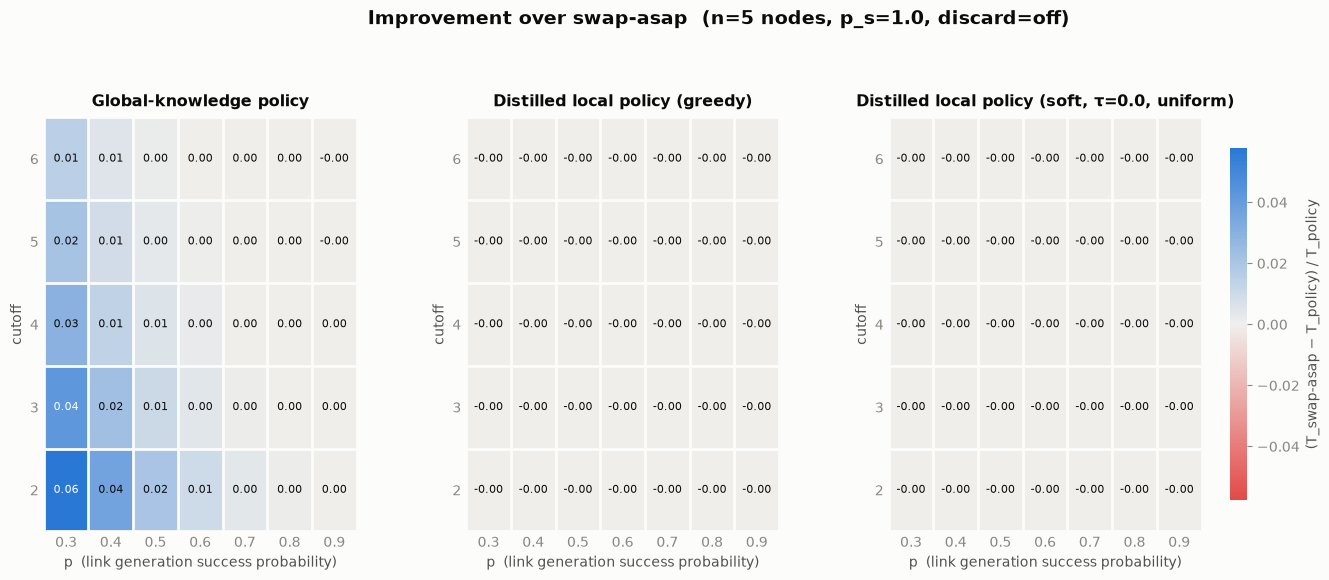

In [12]:
SURFACE = "#fcfcfb"
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"

# Diverging blue <-> red pair with a neutral gray midpoint at zero.
DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "blue_gray_red", ["#e34948", "#f0efec", "#2a78d6"]
)


def _text_color_for(rgba):
    """Ink or white, whichever contrasts with a cell's fill."""
    luminance = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
    return INK_PRIMARY if luminance > 0.6 else "#ffffff"


def draw_heatmap(ax, matrix, norm, title):
    im = ax.imshow(matrix, cmap=DIVERGING_CMAP, norm=norm, aspect="auto", origin="lower")

    ax.set_xticks(range(len(P_VALUES)))
    ax.set_xticklabels([f"{p:.1f}" for p in P_VALUES], color=INK_MUTED)
    ax.set_yticks(range(len(CUTOFF_VALUES)))
    ax.set_yticklabels(CUTOFF_VALUES, color=INK_MUTED)
    ax.set_xlabel("p  (link generation success probability)", color=INK_SECONDARY)
    ax.set_ylabel("cutoff", color=INK_SECONDARY)
    ax.set_title(title, color=INK_PRIMARY, fontsize=11.5, fontweight="semibold", pad=8)

    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(length=0)

    # A thin surface-color gap between cells, so neighbors read as distinct
    # without drawing a border around every cell.
    ax.set_xticks(np.arange(-0.5, len(P_VALUES), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(CUTOFF_VALUES), 1), minor=True)
    ax.grid(which="minor", color=SURFACE, linewidth=2)
    ax.tick_params(which="minor", length=0)

    for row in range(matrix.shape[0]):
        for col in range(matrix.shape[1]):
            value = matrix[row, col]
            text_color = _text_color_for(im.cmap(im.norm(value)))
            ax.text(col, row, f"{value:.2f}", ha="center", va="center",
                     color=text_color, fontsize=8)

    return im


combined = np.concatenate([ratio_global.ravel(), ratio_distilled.ravel(), ratio_soft.ravel()])
vmax = float(np.nanmax(np.abs(combined)))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

_weighting_label = "visitation-weighted" if VISITATION_WEIGHTED else "uniform"

fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor=SURFACE)
for ax, matrix, title in zip(
    axes,
    [ratio_global, ratio_distilled, ratio_soft],
    ["Global-knowledge policy", "Distilled local policy (greedy)",
     f"Distilled local policy (soft, τ={TEMPERATURE}, {_weighting_label})"],
):
    ax.set_facecolor(SURFACE)
    im = draw_heatmap(ax, matrix, norm, title)

fig.subplots_adjust(top=0.80, wspace=0.35)

cbar = fig.colorbar(im, ax=axes, shrink=0.85, pad=0.02)
cbar.set_label("(T_swap-asap − T_policy) / T_policy", color=INK_SECONDARY)
cbar.ax.yaxis.set_tick_params(color=INK_MUTED, labelcolor=INK_MUTED)
cbar.outline.set_visible(False)

fig.suptitle(
    f"Improvement over swap-asap  (n={N} nodes, p_s={P_S}, discard={'on' if ALLOW_DISCARD else 'off'})",
    color=INK_PRIMARY, fontsize=14, fontweight="semibold", y=0.98,
)
plt.show()

With the defaults above (`n=5`, `p_s=1.0`, `τ=0`, visitation-weighted), the panels tell a striking story — and at `τ=0` there is *no* softmax fuzziness anywhere in the soft panel; it's a fully deterministic, hard-majority policy, exactly like the greedy panel is. The two panels differ only in how they weight each global state's vote (visitation count vs. raw state count), so any difference between them isolates the effect of visitation weighting alone.

At `p ≥ 0.7`, the soft panel matches the greedy panel exactly (0% everywhere). At `p ≤ 0.6`, it's dramatically *worse* than swap-asap — down to −70% at `p=0.3, cutoff=2` — while greedy still collapses cleanly to swap-asap (0%) at every grid point. So visitation weighting isn't a mild perturbation here; at low `p` it's actively picking the *wrong* majority action for some local states.

Why: visitation counts are computed under the **optimal global policy's own** steady-state dynamics — they measure how often the optimal policy (with full network knowledge) visits a state, not how often a *local, uncoordinated* policy actually will once deployed. Those two visitation patterns coincide when the chain has little room to wander (high `p`: links form fast, trajectories are short and converge quickly, so there's not much room for the two visitation distributions to diverge). At low `p`, trajectories are long and the two policies' behavior compounds differently over many steps, so "which states does the *optimal* policy linger in" becomes a progressively worse proxy for "which states will *this* distilled policy actually linger in" — and the majority vote gets computed against the wrong distribution.

Things worth trying from here:
- **Set `VISITATION_WEIGHTED = False`** and re-run — the soft panel should then match the greedy panel exactly, everywhere (not just at high `p`), confirming visitation weighting is the whole story at `τ=0`, not an artifact of this particular grid.
- **Raise `TEMPERATURE` above 0** — since temperature only ever moves probability mass *away* from the majority action, it can't recover the low-`p` gap above; expect it to add further degradation on top, not fix it.
- **Try other `n`** — note that policy iteration's cost grows quickly with `n`, so larger grids will take longer on the first (uncached) run.